In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset

In [2]:
class LensingDataset1D(Dataset):
    def __init__(self, root_dir, target_length=None, augment=False):
        self.root_dir = root_dir
        self.target_length = target_length 
        self.augment = augment # Enable for Train, disable for Val
        self.image_paths = []
        self.labels = []
        self.class_map = {'no': 0, 'sphere': 1, 'vort': 2}

        for class_name, class_idx in self.class_map.items():
            class_folder = os.path.join(root_dir, class_name)
            if not os.path.exists(class_folder): continue
            files = glob.glob(os.path.join(class_folder, "*.npy"))
            for f in files:
                self.image_paths.append(f)
                self.labels.append(class_idx)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        data = np.load(self.image_paths[idx]).squeeze()
        if len(data.shape) > 1: data = data.flatten()
        
        # --- DATA AUGMENTATION (Training only) ---
        if self.augment:
            # 1. Random Flip
            if np.random.random() > 0.5:
                data = np.flip(data)
            
            # 2. Random Shift (Roll)
            shift = np.random.randint(-50, 50)
            data = np.roll(data, shift)
            
            # 3. Add Gaussian Noise
            noise = np.random.normal(0, 0.01, data.shape)
            data = data + noise

        # Physics Stretch
        stretch_factor = 10.0 
        data = np.arcsinh(data * stretch_factor) / np.arcsinh(stretch_factor)
        
        data = torch.FloatTensor(data.copy()).unsqueeze(0) # (1, Length)
        
        if self.target_length is not None and data.shape[-1] != self.target_length:
            data = torch.nn.functional.interpolate(
                data.unsqueeze(0), size=self.target_length, mode='linear', align_corners=False
            ).squeeze(0)

        return data, self.labels[idx]

In [3]:

import os
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
train_dir = '/kaggle/input/datasets/saxenaitis/deeplensetask0/dataset/train'
val_dir = '/kaggle/input/datasets/saxenaitis/deeplensetask0/dataset/val'

train_ds = LensingDataset1D(train_dir, target_length=9216,augment = True)
val_ds = LensingDataset1D(val_dir, target_length=9216)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds,batch_size=64,shuffle=False)

# Now this should work without errors!
images, labels = next(iter(train_loader))
print(images.shape) # Output: [64, 1, 9216]

torch.Size([64, 1, 9216])


In [4]:
def conv_bn_relu1d(inp, oup, stride):
    return nn.Sequential(
        nn.Conv1d(inp, oup, kernel_size=3, stride=stride, padding=1, bias=False),
        nn.BatchNorm1d(oup),
        nn.ReLU6(inplace=True)
    )

class InvertedResidual1d(nn.Module):
    def __init__(self, inp, oup, stride, expand_ratio):
        super().__init__()
        self.stride = stride
        hidden_dim = int(inp * expand_ratio)
        self.use_res_connect = self.stride == 1 and inp == oup

        layers = []
        if expand_ratio != 1:
            # Pointwise expansion
            layers.append(nn.Conv1d(inp, hidden_dim, 1, 1, 0, bias=False))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU6(inplace=True))
        
        layers.extend([
            # Depthwise convolution
            nn.Conv1d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU6(inplace=True),
            # Pointwise linear projection (bottleneck)
            nn.Conv1d(hidden_dim, oup, 1, 1, 0, bias=False),
            nn.BatchNorm1d(oup),
        ])
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.conv(x)
        return self.conv(x)

class MobileNetV2_1D(nn.Module):
    def __init__(self, num_classes=3, input_channels=1):
        super().__init__()
        # Initial layer
        self.features = [conv_bn_relu1d(input_channels, 32, stride=2)]
        
        # Configuration: t (expand), c (channels), n (repeats), s (stride)
        configs = [
            [1, 16, 1, 1],
            [6, 24, 2, 2],
            [6, 32, 3, 2],
            [6, 64, 4, 2],
            [6, 96, 3, 1],
        ]
        
        input_channel = 32
        for t, c, n, s in configs:
            for i in range(n):
                stride = s if i == 0 else 1
                self.features.append(InvertedResidual1d(input_channel, c, stride, t))
                input_channel = c
        
        self.features = nn.Sequential(*self.features)
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(input_channel, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.mean(2) # Global Average Pooling over the 1D length
        x = self.classifier(x)
        return x

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from tqdm.auto import tqdm
import torch.nn.functional as F
import numpy as np

import copy # Used to save the best model weights in memory

In [6]:
import copy
import torch
import os
import numpy as np
import torch.nn.functional as F
from tqdm.auto import tqdm

def run_training(model, train_loader, val_loader, epochs=15, patience=3):
    # 1. Setup Kaggle paths
    output_dir = "/kaggle/working/"
    best_model_path = os.path.join(output_dir, "best_lensing_model.pth")
    last_checkpoint_path = os.path.join(output_dir, "last_checkpoint.pth")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Early Stopping Variables
    best_val_loss = float('inf')
    epochs_no_improve = 0
    early_stop = False

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        if early_stop:
            print(f"!!! Early stopping triggered at epoch {epoch} !!!")
            break

        # --- TRAIN PHASE ---
        model.train()
        train_loss, train_acc = 0, 0
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        
        for x, y in train_bar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_acc += (out.argmax(1) == y).float().mean().item()
            train_bar.set_postfix(loss=loss.item())
        
        # --- VALIDATE PHASE ---
        model.eval()
        val_loss, val_acc = 0, 0
        all_probs, all_labels = [], []
        
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]")
        with torch.no_grad():
            for x, y in val_bar:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                
                val_loss += loss.item()
                val_acc += (out.argmax(1) == y).float().mean().item()
                
                all_probs.append(F.softmax(out, dim=1).cpu().numpy())
                all_labels.append(y.cpu().numpy())

        scheduler.step()
        
        # Calculate Averages
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        avg_train_acc = train_acc / len(train_loader)
        avg_val_acc = val_acc / len(val_loader)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(avg_train_acc)
        history['val_acc'].append(avg_val_acc)
        
        print(f"Summary -> Loss: {avg_val_loss:.4f} | Acc: {avg_val_acc:.4f}")

        # --- SAVE BEST MODEL & EARLY STOPPING ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            
            # Save weights to Kaggle /working directory
            torch.save(model.state_dict(), best_model_path)
            print(f"✓ Best weights saved to: {best_model_path}")
        else:
            epochs_no_improve += 1
            print(f"× No improvement for {epochs_no_improve} epochs.")
            if epochs_no_improve >= patience:
                early_stop = True

    # --- SAVE FINAL CHECKPOINT (Weights + Optimizer state) ---
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history
    }
    torch.save(checkpoint, last_checkpoint_path)
    print(f"Final checkpoint saved to: {last_checkpoint_path}")

    # Load best weights back for ROC calculation
    model.load_state_dict(torch.load(best_model_path))
    
    y_true = np.concatenate(all_labels)
    y_probs = np.concatenate(all_probs)
    
    return history, y_true, y_probs

In [7]:
from sklearn.preprocessing import label_binarize
def plot_performance(history, y_true, y_probs):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
    # --- 1. Loss Curve ---
    ax[0].plot(history['train_loss'], label='Train Loss', color='blue', lw=2)
    ax[0].plot(history['val_loss'], label='Val Loss', color='red', lw=2, linestyle='--')
    ax[0].set_title('Training & Validation Loss')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    # --- 2. ROC Curve ---
    # Binarize labels for 3-class ROC
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    n_classes = 3
    class_names = ['No Substructure', 'Sphere', 'Vortex']
    colors = ['cyan', 'magenta', 'orange']

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax[1].plot(fpr, tpr, color=colors[i], lw=2,
                   label=f'ROC {class_names[i]} (AUC = {roc_auc:.2f})')

    ax[1].plot([0, 1], [0, 1], 'k--', lw=1) # Diagonal line
    ax[1].set_xlim([0.0, 1.0])
    ax[1].set_ylim([0.0, 1.05])
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].set_title('Multi-Class ROC Curve')
    ax[1].legend(loc="lower right")
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [8]:
# # 1. Initialize
model = MobileNetV2_1D(num_classes=3)



history, y_true, y_probs = run_training(model, train_loader, val_loader, epochs=50, patience=5)

# 3. Plot


Epoch 1/50 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/118 [00:00<?, ?it/s]

Summary -> Loss: 1.0659 | Acc: 0.4186
✓ Best weights saved to: /kaggle/working/best_lensing_model.pth


Epoch 2/50 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/50 [Val]:   0%|          | 0/118 [00:00<?, ?it/s]

...

Epoch 11/50 [Val]:   0%|          | 0/118 [00:00<?, ?it/s]

Summary -> Loss: 0.9500 | Acc: 0.5617
× No improvement for 4 epochs.


Epoch 12/50 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 12/50 [Val]:   0%|          | 0/118 [00:00<?, ?it/s]

Summary -> Loss: 0.9300 | Acc: 0.5652
× No improvement for 5 epochs.
!!! Early stopping triggered at epoch 12 !!!
Final checkpoint saved to: /kaggle/working/last_checkpoint.pth


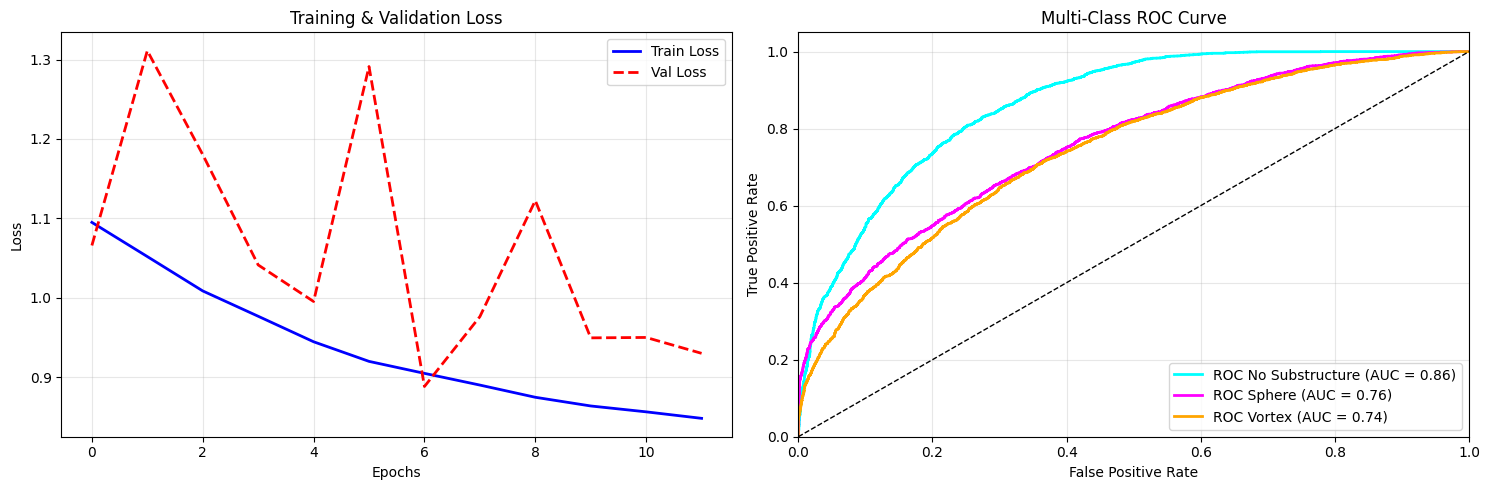

In [9]:
plot_performance(history, y_true, y_probs)